***Preprocessing***

In [1]:
import pandas as pd
import numpy as np

# Load CSV
df = pd.read_csv("studentperformancefactors.csv")

# Check first 5 rows
print(df.head())

   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   
1                         No            8               59              Low   
2                        Yes            7               91           Medium   
3                        Yes            8               98           Medium   
4                        Yes            6               65           Medium   

  Internet_Access  Tutoring_Sessions Family_Income Teacher_Quality  \
0             Ye

In [2]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print(df.columns.tolist())

['hours_studied', 'attendance', 'parental_involvement', 'access_to_resources', 'extracurricular_activities', 'sleep_hours', 'previous_scores', 'motivation_level', 'internet_access', 'tutoring_sessions', 'family_income', 'teacher_quality', 'school_type', 'peer_influence', 'physical_activity', 'learning_disabilities', 'parental_education_level', 'distance_from_home', 'gender', 'exam_score']


In [3]:
X = df.drop('exam_score', axis=1)  # all features
y = df['exam_score']               # target

In [4]:
# Drop rows with any missing value
df.dropna(inplace=True)

# Remove duplicate rows
df.drop_duplicates(inplace=True)

In [5]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical Columns:", categorical_cols)

Categorical Columns: ['parental_involvement', 'access_to_resources', 'extracurricular_activities', 'motivation_level', 'internet_access', 'family_income', 'teacher_quality', 'school_type', 'peer_influence', 'learning_disabilities', 'parental_education_level', 'distance_from_home', 'gender']


In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Encode binary columns
df['gender'] = le.fit_transform(df['gender'])  # Male=1, Female=0

# Encode ordinal columns
ordinal_map = {'Low': 0, 'Medium': 1, 'High': 2}
df['motivation_level'] = df['motivation_level'].map(ordinal_map)
df['internet_access'] = df['internet_access'].map(ordinal_map)

# One-hot encode nominal columns
df = pd.get_dummies(df, columns=['school_type'], drop_first=True)

In [7]:
from sklearn.preprocessing import LabelEncoder

# Binary encoding
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])

# Ordinal mapping
ordinal_mapping = {'Low': 1, 'Medium': 2, 'High': 3}
df['motivation_level'] = df['motivation_level'].map(ordinal_mapping)
df['teacher_quality'] = df['teacher_quality'].map(ordinal_mapping)

# One-hot encoding for nominal
df = pd.get_dummies(df, columns=['school_type_Public'], drop_first=True)

In [8]:
from sklearn.model_selection import train_test_split

X = df.drop('exam_score', axis=1)
y = df['exam_score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

***Regression Models***

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

In [10]:
df = pd.read_csv("studentperformancefactors.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (6607, 20)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [11]:
for col in df.columns:
    
    if df[col].dtype in ['int64','float64']:
        df[col] = df[col].fillna(df[col].mean())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

print("Missing Values After Cleaning:\n")
print(df.isnull().sum())

Missing Values After Cleaning:

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64


In [12]:
df_encoded = pd.get_dummies(df, drop_first=True)

print("Encoded Dataset Shape:", df_encoded.shape)
df_encoded.head()

Encoded Dataset Shape: (6607, 28)


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score,Parental_Involvement_Low,Parental_Involvement_Medium,Access_to_Resources_Low,...,Teacher_Quality_Medium,School_Type_Public,Peer_Influence_Neutral,Peer_Influence_Positive,Learning_Disabilities_Yes,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Distance_from_Home_Moderate,Distance_from_Home_Near,Gender_Male
0,23,84,7,73,0,3,67,True,False,False,...,True,True,False,True,False,True,False,False,True,True
1,19,64,8,59,2,4,61,True,False,False,...,True,True,False,False,False,False,False,True,False,False
2,24,98,7,91,2,4,74,False,True,False,...,True,True,True,False,False,False,True,False,True,True
3,29,89,8,98,1,4,71,True,False,False,...,True,True,False,False,False,True,False,True,False,True
4,19,92,6,65,3,4,70,False,True,False,...,False,True,True,False,False,False,False,False,True,False


In [13]:
numeric_df = df_encoded.select_dtypes(include=['int64','float64'])

Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)

IQR = Q3 - Q1

outlier_condition = ((numeric_df < (Q1 - 1.5 * IQR)) |
                     (numeric_df > (Q3 + 1.5 * IQR)))

df_clean = df_encoded[~outlier_condition.any(axis=1)]

print("Dataset Shape After Removing Outliers:", df_clean.shape)

Dataset Shape After Removing Outliers: (6054, 28)


In [14]:
X = df_clean.drop("Exam_Score", axis=1)
y = df_clean["Exam_Score"]

print("Independent Variables Shape:", X.shape)
print("Target Variable Shape:", y.shape)

Independent Variables Shape: (6054, 27)
Target Variable Shape: (6054,)


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (4843, 27)
Testing Shape: (1211, 27)


In [16]:
linear_model = LinearRegression()

ridge_model = Ridge(alpha=1.0)

lasso_model = Lasso(alpha=0.1)

elastic_model = ElasticNet(alpha=0.1, l1_ratio=0.5)

poly = PolynomialFeatures(degree=2)

In [17]:
linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression R2:", r2_linear)
print("Linear Regression MSE:", mse_linear)

Linear Regression R2: 0.9893384969466352
Linear Regression MSE: 0.10693186856465517


In [18]:
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_model = LinearRegression()

poly_model.fit(X_train_poly, y_train)

y_pred_poly = poly_model.predict(X_test_poly)

mse_poly = mean_squared_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print("Polynomial Regression R2:", r2_poly)
print("Polynomial Regression MSE:", mse_poly)

Polynomial Regression R2: 0.9881752789597524
Polynomial Regression MSE: 0.11859861688924007


In [19]:
ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)

mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Regression R2:", r2_ridge)
print("Ridge Regression MSE:", mse_ridge)

Ridge Regression R2: 0.9893317181485094
Ridge Regression MSE: 0.106999857997908


In [20]:
lasso_model.fit(X_train, y_train)

y_pred_lasso = lasso_model.predict(X_test)

mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("Lasso Regression R2:", r2_lasso)
print("Lasso Regression MSE:", mse_lasso)

Lasso Regression R2: 0.8706694109655991
Lasso Regression MSE: 1.297149330520656


In [21]:
elastic_model.fit(X_train, y_train)

y_pred_elastic = elastic_model.predict(X_test)

mse_elastic = mean_squared_error(y_test, y_pred_elastic)
r2_elastic = r2_score(y_test, y_pred_elastic)

print("Elastic Net R2:", r2_elastic)
print("Elastic Net MSE:", mse_elastic)

Elastic Net R2: 0.9115779747550748
Elastic Net MSE: 0.8868479739099223


In [22]:
results = pd.DataFrame({
    
    "Model": [
        "Linear Regression",
        "Polynomial Regression",
        "Ridge Regression",
        "Lasso Regression",
        "Elastic Net Regression"
    ],
    
    "MSE": [
        mse_linear,
        mse_poly,
        mse_ridge,
        mse_lasso,
        mse_elastic
    ],
    
    "R2": [
        r2_linear,
        r2_poly,
        r2_ridge,
        r2_lasso,
        r2_elastic
    ]
})

print("MODEL COMPARISON")
print(results)

MODEL COMPARISON
                    Model       MSE        R2
0       Linear Regression  0.106932  0.989338
1   Polynomial Regression  0.118599  0.988175
2        Ridge Regression  0.107000  0.989332
3        Lasso Regression  1.297149  0.870669
4  Elastic Net Regression  0.886848  0.911578


In [23]:
best_index = results["R2"].idxmax()

best_model_name = results.loc[best_index,"Model"]

print("Best Model:", best_model_name)

Best Model: Linear Regression


In [24]:
if best_model_name == "Linear Regression":
    
    intercept = linear_model.intercept_
    coef = linear_model.coef_
    feature_names = X.columns
    predictions = y_pred_linear


elif best_model_name == "Ridge Regression":
    
    intercept = ridge_model.intercept_
    coef = ridge_model.coef_
    feature_names = X.columns
    predictions = y_pred_ridge


elif best_model_name == "Lasso Regression":
    
    intercept = lasso_model.intercept_
    coef = lasso_model.coef_
    feature_names = X.columns
    predictions = y_pred_lasso


elif best_model_name == "Elastic Net Regression":
    
    intercept = elastic_model.intercept_
    coef = elastic_model.coef_
    feature_names = X.columns
    predictions = y_pred_elastic


else:
    
    intercept = poly_model.intercept_
    coef = poly_model.coef_
    feature_names = poly.get_feature_names_out(X.columns)
    predictions = y_pred_poly


equation = "Exam_Score = " + str(intercept)

for i in range(len(coef)):
    
    equation += " + (" + str(coef[i]) + " * " + feature_names[i] + ")"

print("\nRegression Equation:\n")
print(equation)


Regression Equation:

Exam_Score = 40.88531496740642 + (0.2979538188416954 * Hours_Studied) + (0.19992464135477692 * Attendance) + (0.014392983814511104 * Sleep_Hours) + (0.04938992741413572 * Previous_Scores) + (0.4997464728241538 * Tutoring_Sessions) + (0.23621425429882428 * Physical_Activity) + (-1.9869698700454723 * Parental_Involvement_Low) + (-1.0031017496806127 * Parental_Involvement_Medium) + (-1.9960050895046175 * Access_to_Resources_Low) + (-0.9846006381262552 * Access_to_Resources_Medium) + (0.5050920009568634 * Extracurricular_Activities_Yes) + (-1.0094593297239614 * Motivation_Level_Low) + (-0.49614558161508826 * Motivation_Level_Medium) + (1.0102379448096843 * Internet_Access_Yes) + (-0.9807365183310093 * Family_Income_Low) + (-0.4859189829885608 * Family_Income_Medium) + (-0.9950686802538682 * Teacher_Quality_Low) + (-0.49452855916490124 * Teacher_Quality_Medium) + (-0.003220723404401011 * School_Type_Public) + (0.49786340381931365 * Peer_Influence_Neutral) + (1.0065376

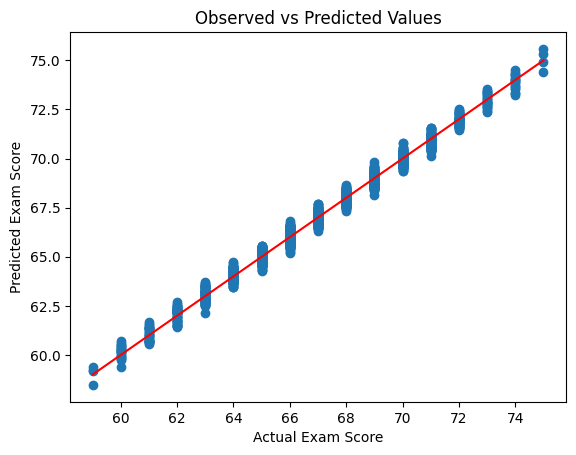

In [25]:
plt.scatter(y_test, predictions)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")

plt.title("Observed vs Predicted Values")

plt.show()

***Classification Model***

In [26]:
# Import Libraries

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report,confusion_matrix

In [27]:
#Load Dataset


df = pd.read_csv("studentperformancefactors.csv")

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (6607, 20)
   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   
1                         No            8               59              Low   
2                        Yes            7               91           Medium   
3                        Yes            8               98           Medium   
4                        Yes            6               65           Medium   

  Internet_Access  Tutoring_Sessions Family_Income Teacher_Q

In [28]:
#Handle Missing Values

for col in df.columns:

    if df[col].dtype in ['int64','float64']:
        df[col] = df[col].fillna(df[col].mean())

    else:
        df[col] = df[col].fillna(df[col].mode()[0])

print("Missing Values After Cleaning")
print(df.isnull().sum())

Missing Values After Cleaning
Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64


In [29]:
# Encode Categorical Variables

df_encoded = pd.get_dummies(df, drop_first=True)

print("Encoded Dataset Shape:", df_encoded.shape)

Encoded Dataset Shape: (6607, 28)


In [30]:
# Convert Exam Score to Categories

def categorize_score(score):

    if score < 50:
        return "Low"

    elif score < 70:
        return "Medium"

    else:
        return "High"


df_encoded["Score_Category"] = df_encoded["Exam_Score"].apply(categorize_score)

print(df_encoded["Score_Category"].value_counts())

Score_Category
Medium    4982
High      1625
Name: count, dtype: int64


In [31]:
# Define X and y


X = df_encoded.drop(["Exam_Score","Score_Category"], axis=1)

y = df_encoded["Score_Category"]

In [32]:
#Train Test Split


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Size:", X_train.shape)
print("Testing Size:", X_test.shape)

Training Size: (5285, 27)
Testing Size: (1322, 27)


In [33]:
#Initialize Models

log_model = LogisticRegression(max_iter=500)

knn_model = KNeighborsClassifier(n_neighbors=5)

svm_model = SVC()

dt_model = DecisionTreeClassifier()

rf_model = RandomForestClassifier()

In [34]:
#Train and Evaluate Models

models = {
    "Logistic Regression": log_model,
    "KNN": knn_model,
    "SVM": svm_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    cm = confusion_matrix(y_test, y_pred)

    results.append([name, acc, prec, rec, f1])

    print("\n========================")
    print("Model:", name)
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)
    print("\nConfusion Matrix:")
    print(cm)

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Model: Logistic Regression
Accuracy: 0.9848714069591528
Precision: 0.9848508899263
Recall: 0.9848714069591528
F1 Score: 0.9848143878409482

Confusion Matrix:
[[334  14]
 [  6 968]]

Classification Report
              precision    recall  f1-score   support

        High       0.98      0.96      0.97       348
      Medium       0.99      0.99      0.99       974

    accuracy                           0.98      1322
   macro avg       0.98      0.98      0.98      1322
weighted avg       0.98      0.98      0.98      1322


Model: KNN
Accuracy: 0.8736762481089259
Precision: 0.8706503923709522
Recall: 0.8736762481089259
F1 Score: 0.8713073065727155

Confusion Matrix:
[[246 102]
 [ 65 909]]

Classification Report
              precision    recall  f1-score   support

        High       0.79      0.71      0.75       348
      Medium       0.90      0.93      0.92       974

    accuracy                           0.87      1322
   macro avg       0.85      0.82      0.83      1322
weig

In [35]:
#Compare Models
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    prec = precision_score(y_test, y_pred, average='weighted')

    rec = recall_score(y_test, y_pred, average='weighted')

    f1 = f1_score(y_test, y_pred, average='weighted')

    cm = confusion_matrix(y_test, y_pred)

    # Save all metrics including confusion matrix
    results.append([
        name,
        acc,
        prec,
        rec,
        f1,
        cm
    ])


results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Confusion Matrix"
    ]
)

print("\nModel Comparison Table")
print(results_df)

C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Model Comparison Table
                 Model  Accuracy  Precision    Recall  F1 Score  \
0  Logistic Regression  0.984871   0.984851  0.984871  0.984814   
1                  KNN  0.873676   0.870650  0.873676  0.871307   
2                  SVM  0.889561   0.887382  0.889561  0.885865   
3        Decision Tree  0.866112   0.866236  0.866112  0.866174   
4        Random Forest  0.919062   0.922201  0.919062  0.915124   

          Confusion Matrix  
0    [[334, 14], [6, 968]]  
1  [[246, 102], [65, 909]]  
2  [[244, 104], [42, 932]]  
3   [[260, 88], [89, 885]]  
4   [[252, 96], [11, 963]]  


In [36]:
#Best Model

best_model_index = results_df["Accuracy"].idxmax()

best_model_name = results_df.loc[best_model_index,"Model"]

print("\nBest Classification Model:", best_model_name)


Best Classification Model: Logistic Regression


In [37]:
#Count Elements in Each Category


print("\nNumber of Elements in Each Category")

print(df_encoded["Score_Category"].value_counts())


Number of Elements in Each Category
Score_Category
Medium    4982
High      1625
Name: count, dtype: int64


***Cluster Analysis***

In [38]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [39]:
#Select Features
features = df_encoded[[
    "Hours_Studied",
    "Attendance",
    "Sleep_Hours",
    "Previous_Scores",
    "Exam_Score"
]]

print(features.head())

   Hours_Studied  Attendance  Sleep_Hours  Previous_Scores  Exam_Score
0             23          84            7               73          67
1             19          64            8               59          61
2             24          98            7               91          74
3             29          89            8               98          71
4             19          92            6               65          70


In [40]:
#Feature Scaling

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

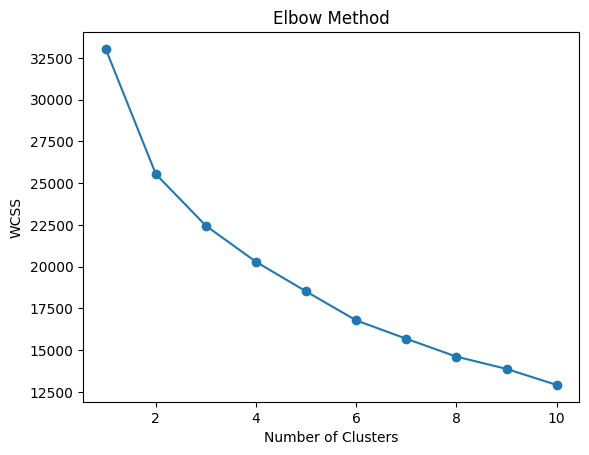

In [41]:
# Elbow Method

wcss = []

for i in range(1,11):

    kmeans = KMeans(n_clusters=i, random_state=42)

    kmeans.fit(scaled_features)

    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

In [42]:
#Apply K-Means

kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(scaled_features)

df_encoded["Cluster"] = clusters

print(df_encoded["Cluster"].value_counts())

Cluster
2    2472
0    2159
1    1976
Name: count, dtype: int64


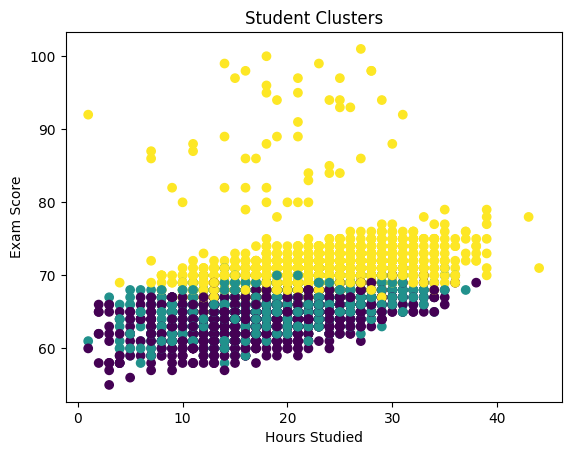

In [43]:
# Cluster Visualization

plt.scatter(
    df_encoded["Hours_Studied"],
    df_encoded["Exam_Score"],
    c=df_encoded["Cluster"]
)

plt.xlabel("Hours Studied")

plt.ylabel("Exam Score")

plt.title("Student Clusters")

plt.show()